In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/Global_Oral.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done Extraction")

Mounted at /content/drive
Done Extraction


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import json

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder("/content/data/train", transform=transform)
val_data   = datasets.ImageFolder("/content/data/valid", transform=transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.densenet121(pretrained=True)

# Modify classifier
model.classifier = nn.Linear(model.classifier.in_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 124MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
save_path = "/content/drive/MyDrive/densenet_checkpoint.pth"
log_path  = "/content/drive/MyDrive/densenet_log.json"

start_epoch = 0
history = {"loss": [], "accuracy": []}

# Resume if exists
if os.path.exists(save_path):
    checkpoint = torch.load(save_path)
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    start_epoch = checkpoint['epoch']

    with open(log_path, "r") as f:
        history = json.load(f)

    print("Resuming from epoch:", start_epoch)

In [ ]:
epochs = 20

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    # Save history
    history["loss"].append(epoch_loss)
    history["accuracy"].append(epoch_acc)

    # SAVE CHECKPOINT
    torch.save({
        'epoch': epoch + 1,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict()
    }, save_path)

    # SAVE JSON LOG
    with open(log_path, "w") as f:
        json.dump(history, f)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/20 | Loss: 0.2055 | Acc: 0.9163
Epoch 2/20 | Loss: 0.0728 | Acc: 0.9746
Epoch 3/20 | Loss: 0.0458 | Acc: 0.9858
Epoch 4/20 | Loss: 0.0367 | Acc: 0.9876
Epoch 5/20 | Loss: 0.0504 | Acc: 0.9831
Epoch 6/20 | Loss: 0.0321 | Acc: 0.9900
Epoch 7/20 | Loss: 0.0217 | Acc: 0.9933
Epoch 8/20 | Loss: 0.0176 | Acc: 0.9949
Epoch 9/20 | Loss: 0.0119 | Acc: 0.9964
Epoch 10/20 | Loss: 0.0203 | Acc: 0.9933
Epoch 11/20 | Loss: 0.0323 | Acc: 0.9876
Epoch 12/20 | Loss: 0.0284 | Acc: 0.9912
Epoch 13/20 | Loss: 0.0129 | Acc: 0.9958
Epoch 14/20 | Loss: 0.0059 | Acc: 0.9985
Epoch 15/20 | Loss: 0.0058 | Acc: 0.9982
Epoch 16/20 | Loss: 0.0038 | Acc: 0.9985
Epoch 17/20 | Loss: 0.0027 | Acc: 0.9985
Epoch 18/20 | Loss: 0.0113 | Acc: 0.9964
Epoch 19/20 | Loss: 0.0452 | Acc: 0.9870
Epoch 20/20 | Loss: 0.0501 | Acc: 0.9843


In [ ]:
import torch
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("/content/drive/MyDrive/densenet_checkpoint.pth")
model.load_state_dict(checkpoint['model'])
model.to(device)
model.eval()

with open("/content/drive/MyDrive/densenet_log.json","r") as f:
    history = json.load(f)

In [ ]:
import numpy as np

In [ ]:
def evaluate(loader):
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# VALIDATION
val_labels, val_preds = evaluate(val_loader)

# TEST
test_data = datasets.ImageFolder("/content/data/test", transform=transform)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

test_labels, test_preds = evaluate(test_loader)

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred) * 100
    rec = recall_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred) * 100

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    specificity = (tn / (tn + fp)) * 100
    sensitivity = rec  # same as recall

    return acc, prec, rec, f1, specificity, sensitivity, cm

acc, prec, rec, f1, spec, sens, cm = get_metrics(test_labels, test_preds)

print(f"Accuracy: {acc:.2f}%")
print(f"Precision: {prec:.2f}%")
print(f"Sensitivity: {sens:.2f}%")
print(f"Specificity: {spec:.2f}%")
print(f"F1 Score: {f1:.2f}%")

Accuracy: 97.10%
Precision: 94.93%
Sensitivity: 99.52%
Specificity: 94.69%
F1 Score: 97.17%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

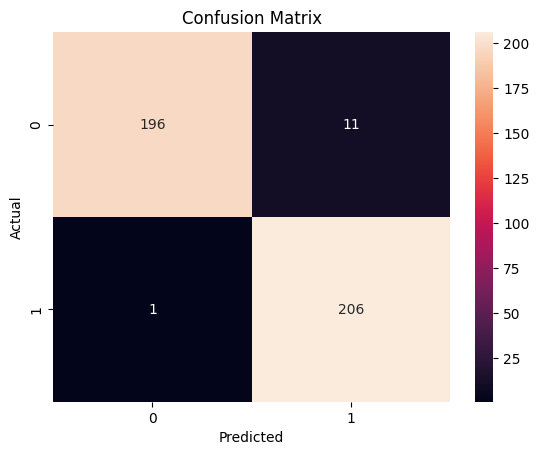

In [ ]:
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("/content/drive/MyDrive/confusion_matrix.png")
plt.show()

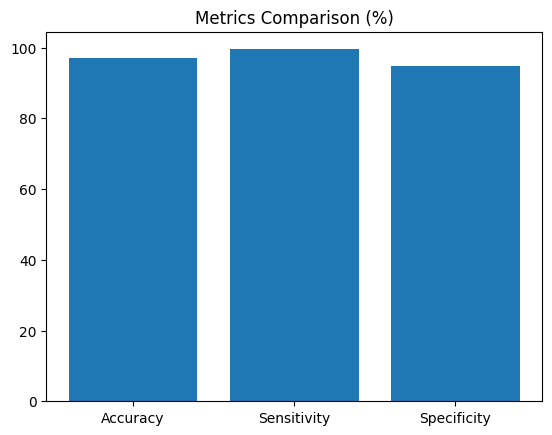

In [ ]:
metrics = [acc, sens, spec]
labels = ["Accuracy", "Sensitivity", "Specificity"]

plt.figure()
plt.bar(labels, metrics)
plt.title("Metrics Comparison (%)")

plt.savefig("/content/drive/MyDrive/metrics_bar.png")
plt.show()

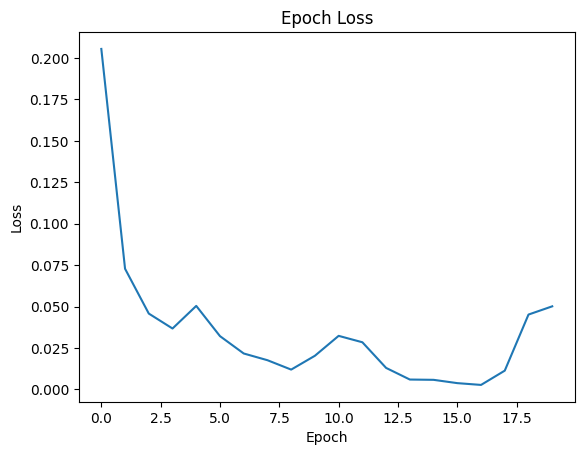

In [ ]:
plt.figure()
plt.plot(history["loss"])
plt.title("Epoch Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig("/content/drive/MyDrive/loss_graph.png")
plt.show()

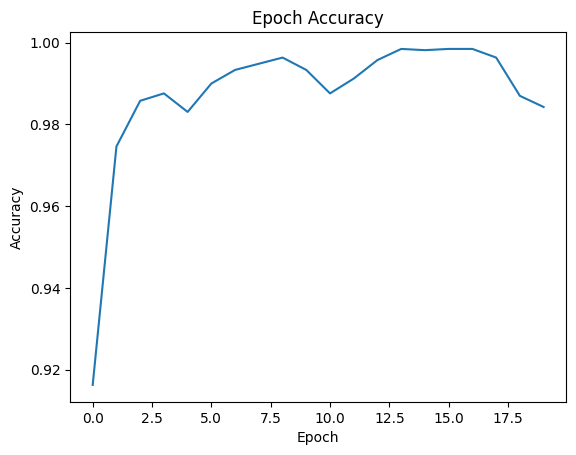

In [ ]:
plt.figure()
plt.plot(history["accuracy"])
plt.title("Epoch Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig("/content/drive/MyDrive/accuracy_graph.png")
plt.show()

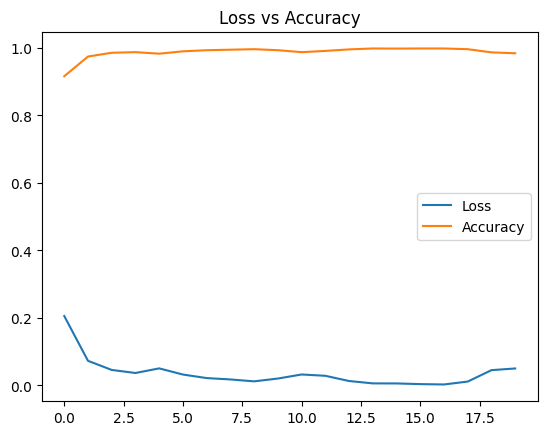

In [ ]:
plt.figure()
plt.plot(history["loss"], label="Loss")
plt.plot(history["accuracy"], label="Accuracy")
plt.legend()
plt.title("Loss vs Accuracy")

plt.savefig("/content/drive/MyDrive/combined_graph.png")
plt.show()

In [ ]:
import os, json, torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 📂 SAVE DIRECTORY
SAVE_DIR = "/content/drive/MyDrive/DenseNet_Final/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------- 1. SAVE FINAL MODEL ----------
torch.save({
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict()
}, SAVE_DIR + "final_model.pth")

# ---------- 2. LOAD HISTORY ----------
with open("/content/drive/MyDrive/densenet_full_log.json", "r") as f:
    history = json.load(f)

# ---------- 3. GET PREDICTIONS ----------
def get_preds(loader):
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_preds(test_loader)

# ---------- 4. METRICS (IN %) ----------
acc = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred) * 100
recall = recall_score(y_true, y_pred) * 100
f1 = f1_score(y_true, y_pred) * 100

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = (tn / (tn + fp)) * 100

metrics = {
    "accuracy": acc,
    "precision": precision,
    "recall": recall,
    "specificity": specificity,
    "f1_score": f1
}

# SAVE METRICS JSON
with open(SAVE_DIR + "final_metrics.json", "w") as f:
    json.dump(metrics, f)

print(metrics)

# ---------- 5. CONFUSION MATRIX ----------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.savefig(SAVE_DIR + "confusion_matrix.png")
plt.close()

# ---------- 6. BAR GRAPH ----------
plt.figure()
plt.bar(["Accuracy","Sensitivity","Specificity"], [acc, recall, specificity])
plt.title("Metrics (%)")
plt.savefig(SAVE_DIR + "metrics_bar.png")
plt.close()

# ---------- 7. TRAINING GRAPHS ----------
loss = history["loss"]
accuracy = history["accuracy"]

# Loss
plt.figure()
plt.plot(loss)
plt.title("Epoch Loss")
plt.savefig(SAVE_DIR + "loss.png")
plt.close()

# Accuracy
plt.figure()
plt.plot(accuracy)
plt.title("Epoch Accuracy")
plt.savefig(SAVE_DIR + "accuracy.png")
plt.close()

# Combined
plt.figure()
plt.plot(loss, label="Loss")
plt.plot(accuracy, label="Accuracy")
plt.legend()
plt.title("Loss vs Accuracy")
plt.savefig(SAVE_DIR + "combined.png")
plt.close()

# ---------- 8. SAVE PREDICTIONS ----------
np.save(SAVE_DIR + "y_true.npy", y_true)
np.save(SAVE_DIR + "y_pred.npy", y_pred)

print("🔥 DENSENET EVERYTHING SAVED SUCCESSFULLY")

{'accuracy': 97.58454106280193, 'precision': 97.58454106280193, 'recall': 97.58454106280193, 'specificity': np.float64(97.58454106280193), 'f1_score': 97.58454106280193}
🔥 DENSENET EVERYTHING SAVED SUCCESSFULLY


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Validation data
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

val_data = datasets.ImageFolder("/content/data/valid", transform=transform)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

# DenseNet121
model = models.densenet121(pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, 2)

criterion = nn.CrossEntropyLoss()

# Change path if needed
checkpoint = torch.load("/content/drive/MyDrive/densenet_checkpoint.pth", map_location=device)

model.load_state_dict(checkpoint["model"])
model.to(device)
model.eval()

print("DenseNet Loaded")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


DenseNet Loaded


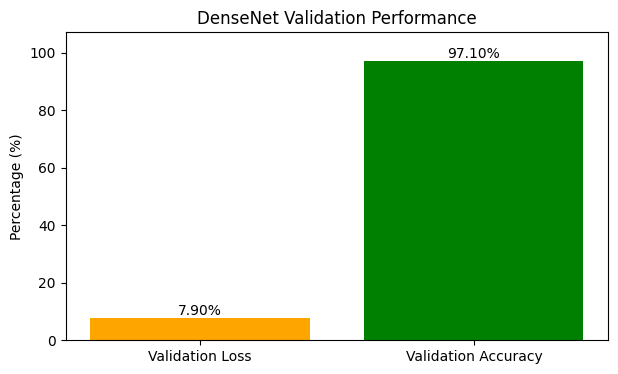

Validation Loss: 0.079
Validation Accuracy: 0.971


In [ ]:
import torch
import matplotlib.pyplot as plt

# Validation
model.eval()
correct = 0
total = 0
running_val_loss = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_val_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

val_loss = running_val_loss / len(val_loader)
val_acc = correct / total

# Convert to %
val_loss_percent = val_loss * 100
val_acc_percent = val_acc * 100

# Graph
values = [val_loss_percent, val_acc_percent]
labels = ["Validation Loss", "Validation Accuracy"]
colors = ["orange", "green"]

plt.figure(figsize=(7,4))
bars = plt.bar(labels, values, color=colors)

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.ylabel("Percentage (%)")
plt.title("DenseNet Validation Performance")
plt.ylim(0, max(values)+10)

plt.savefig("/content/drive/MyDrive/densenet_validation_graph.png")
plt.show()

print("Validation Loss:", round(val_loss,4))
print("Validation Accuracy:", round(val_acc,4))